In [1]:
import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
session = fastf1.get_session(2026, 'Australia', 'Q')
session.load()

results = session.results
print(results)

req         WARNING 	DEFAULT CACHE ENABLED! (569.43 MB) /Users/hemant/Library/Caches/fastf1
core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req          

   DriverNumber BroadcastName Abbreviation        DriverId         TeamName  \
63           63     G RUSSELL          RUS         russell         Mercedes   
12           12   K ANTONELLI          ANT       antonelli         Mercedes   
6             6      I HADJAR          HAD          hadjar  Red Bull Racing   
16           16     C LECLERC          LEC         leclerc          Ferrari   
81           81     O PIASTRI          PIA         piastri          McLaren   
1             1      L NORRIS          NOR          norris          McLaren   
44           44    L HAMILTON          HAM        hamilton          Ferrari   
30           30      L LAWSON          LAW          lawson     Racing Bulls   
41           41    A LINDBLAD          LIN  arvid_lindblad     Racing Bulls   
5             5   G BORTOLETO          BOR       bortoleto             Audi   
27           27  N HULKENBERG          HUL      hulkenberg             Audi   
87           87     O BEARMAN          BEA         b

In [3]:
quali = session.results[['DriverNumber','Position','Abbreviation', 'Q3']]
print(quali)

   DriverNumber  Position Abbreviation                     Q3
63           63       1.0          RUS 0 days 00:01:18.518000
12           12       2.0          ANT 0 days 00:01:18.811000
6             6       3.0          HAD 0 days 00:01:19.303000
16           16       4.0          LEC 0 days 00:01:19.327000
81           81       5.0          PIA 0 days 00:01:19.380000
1             1       6.0          NOR 0 days 00:01:19.475000
44           44       7.0          HAM 0 days 00:01:19.478000
30           30       8.0          LAW 0 days 00:01:19.994000
41           41       9.0          LIN 0 days 00:01:21.247000
5             5      10.0          BOR                    NaT
27           27      11.0          HUL                    NaT
87           87      12.0          BEA                    NaT
31           31      13.0          OCO                    NaT
10           10      14.0          GAS                    NaT
23           23      15.0          ALB                    NaT
43      

In [4]:
race = fastf1.get_session(2026, 'Australia', 'R')
race.load()

race_results = race.results
race_df = race_results[['DriverNumber', 'Position', 'Abbreviation']]
print(race_df)

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

   DriverNumber  Position Abbreviation
63           63       1.0          RUS
12           12       2.0          ANT
16           16       3.0          LEC
44           44       4.0          HAM
1             1       5.0          NOR
3             3       6.0          VER
87           87       7.0          BEA
41           41       8.0          LIN
5             5       9.0          BOR
10           10      10.0          GAS
31           31      11.0          OCO
23           23      12.0          ALB
30           30      13.0          LAW
43           43      14.0          COL
55           55      15.0          SAI
11           11      16.0          PER
18           18      17.0          STR
14           14      18.0          ALO
77           77      19.0          BOT
6             6      20.0          HAD
81           81      21.0          PIA
27           27      22.0          HUL


In [5]:
merged = pd.merge(quali, race_df, on='DriverNumber')
print(merged)

   DriverNumber  Position_x Abbreviation_x                     Q3  Position_y  \
0            63         1.0            RUS 0 days 00:01:18.518000         1.0   
1            12         2.0            ANT 0 days 00:01:18.811000         2.0   
2             6         3.0            HAD 0 days 00:01:19.303000        20.0   
3            16         4.0            LEC 0 days 00:01:19.327000         3.0   
4            81         5.0            PIA 0 days 00:01:19.380000        21.0   
5             1         6.0            NOR 0 days 00:01:19.475000         5.0   
6            44         7.0            HAM 0 days 00:01:19.478000         4.0   
7            30         8.0            LAW 0 days 00:01:19.994000        13.0   
8            41         9.0            LIN 0 days 00:01:21.247000         8.0   
9             5        10.0            BOR                    NaT         9.0   
10           27        11.0            HUL                    NaT        22.0   
11           87        12.0 

In [6]:
merged['Winner'] = merged['Position_y'] == 1
merged['Winner'] = merged['Winner'].astype(int)

print(merged)

   DriverNumber  Position_x Abbreviation_x                     Q3  Position_y  \
0            63         1.0            RUS 0 days 00:01:18.518000         1.0   
1            12         2.0            ANT 0 days 00:01:18.811000         2.0   
2             6         3.0            HAD 0 days 00:01:19.303000        20.0   
3            16         4.0            LEC 0 days 00:01:19.327000         3.0   
4            81         5.0            PIA 0 days 00:01:19.380000        21.0   
5             1         6.0            NOR 0 days 00:01:19.475000         5.0   
6            44         7.0            HAM 0 days 00:01:19.478000         4.0   
7            30         8.0            LAW 0 days 00:01:19.994000        13.0   
8            41         9.0            LIN 0 days 00:01:21.247000         8.0   
9             5        10.0            BOR                    NaT         9.0   
10           27        11.0            HUL                    NaT        22.0   
11           87        12.0 

In [7]:
feature = merged['Position_x']
label = merged['Winner']

X = pd.DataFrame(feature)
y = pd.DataFrame(label)

print(X.shape)
print(y.shape)

(22, 1)
(22, 1)


In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X,y)

/opt/homebrew/Cellar/jupyterlab/4.5.4/libexec/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
model.predict_proba([[1]])

/opt/homebrew/Cellar/jupyterlab/4.5.4/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[0.39, 0.61]])

In [10]:
model.predict_proba([[2]])

/opt/homebrew/Cellar/jupyterlab/4.5.4/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[0.69, 0.31]])

In [11]:
model.predict_proba([[3]])

/opt/homebrew/Cellar/jupyterlab/4.5.4/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[0.92, 0.08]])

In [12]:
model.predict_proba([[4]])

/opt/homebrew/Cellar/jupyterlab/4.5.4/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[1., 0.]])

In [13]:
predictions = []

for i in range(1,10):
    predictions.append(model.predict_proba([[i]])[0][1])

print(predictions)

[np.float64(0.61), np.float64(0.31), np.float64(0.08), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


/opt/homebrew/Cellar/jupyterlab/4.5.4/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.5.4/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.5.4/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.5.4/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.5.4/libexec/lib/python3.14/site-pa

In [14]:
print(predictions)

[np.float64(0.61), np.float64(0.31), np.float64(0.08), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


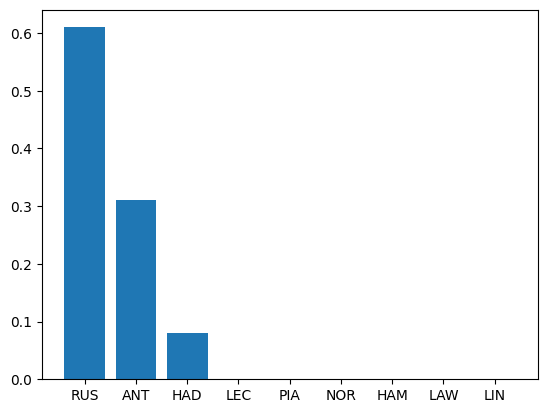

In [19]:
drivers = ['RUS', 'ANT', 'HAD', 'LEC', 'PIA', 'NOR', 'HAM', 'LAW', 'LIN']

plt.bar(drivers, predictions)
plt.show()

In [20]:
# SOO, above was the too simple model yet correct model created. Now let's test this model for the Chinese GP'26!